Explainable and Robust Toxic Comment Classification Using Lightweight Machine Learning Models.

In [22]:
from datasets import load_dataset
import pandas as pd

print("Loading dataset...")

dataset = load_dataset("google/civil_comments")

Loading dataset...


In [23]:
df = dataset["train"].to_pandas()

print(df.shape)

df.head()

(1804874, 8)


,text,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,sexual_explicit
0,"This is so cool. It's like, 'would you want yo...",0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0
1,Thank you!! This would make my life a lot less...,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0
2,This is such an urgent design problem; kudos t...,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0
3,Is this something I'll be able to install on m...,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0
4,haha you guys are a bunch of losers.,0.893617,0.021277,0.0,0.0,0.87234,0.021277,0.0


In [24]:
df["label"] = (df["toxicity"] >= 0.5).astype(int)

print(df["label"].value_counts())

label
0    1660540
1     144334
Name: count, dtype: int64


In [25]:
import re

def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r'http\S+|www\S+', '', text)

    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [26]:
df["clean_text"] = df["text"].apply(clean_text)

print(df[["text", "clean_text"]].head())

                                                text  \
0  This is so cool. It's like, 'would you want yo...   
1  Thank you!! This would make my life a lot less...   
2  This is such an urgent design problem; kudos t...   
3  Is this something I'll be able to install on m...   
4               haha you guys are a bunch of losers.   

                                          clean_text  
0  this is so cool. it's like, 'would you want yo...  
1  thank you!! this would make my life a lot less...  
2  this is such an urgent design problem; kudos t...  
3  is this something i'll be able to install on m...  
4               haha you guys are a bunch of losers.  


In [27]:
print(df.memory_usage(deep=True).sum() / 1024**3)

1.2897943165153265


In [28]:
# # Create research dataset

# df_research = df.sample(
#     n=300000,
#     random_state=42
# )

# print(df_research.shape)

# print(df_research["label"].value_counts(normalize=True))

df_research = df.groupby("label", group_keys=False).apply(
    lambda x: x.sample(frac=300000/len(df), random_state=42)
)

C:\Users\user\AppData\Local\Temp\ipykernel_13516\3180290913.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_research = df.groupby("label", group_keys=False).apply(


In [29]:
# install scikit-learn if missing
%pip install -q scikit-learn

from sklearn.model_selection import train_test_split

X = df_research["clean_text"]

y = df_research["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

Note: you may need to restart the kernel to use updated packages.
(240000,)
(60000,)



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    min_df=5
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(240000, 15000)
(60000, 15000)


Model 1: LogistricRegression

In [31]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_pred = lr.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.9412333333333334
Precision: 0.8315954118873827
Recall: 0.33243017924135054
F1: 0.4749851101846337

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     55202
           1       0.83      0.33      0.47      4798

    accuracy                           0.94     60000
   macro avg       0.89      0.66      0.72     60000
weighted avg       0.94      0.94      0.93     60000



In [33]:
results = []

results.append({
    "Model":"Logistic Regression",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1":f1
})

results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.9412333333333334,
  'Precision': 0.8315954118873827,
  'Recall': 0.33243017924135054,
  'F1': 0.4749851101846337}]

Model 2:naive bayes

In [34]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Accuracy:", accuracy_nb)
print("Precision:", precision_nb)
print("Recall:", recall_nb)
print("F1:", f1_nb)

Accuracy: 0.9229833333333334
Precision: 0.9154929577464789
Recall: 0.04064193413922468
F1: 0.07782877669127919


model 3: linear SVM

In [35]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    random_state=42
)

svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1:", f1_svm)

Accuracy: 0.9431166666666667
Precision: 0.7656309934790947
Recall: 0.41600666944560233
F1: 0.5390952059419312


In [36]:
results = []

results.append({
    "Model":"Logistic Regression",
    "Feature":"TF-IDF",
    "Accuracy":0.94025,
    "Precision":0.8192,
    "Recall":0.3317,
    "F1":0.4723
})

results.append({
    "Model":"Naive Bayes",
    "Feature":"TF-IDF",
    "Accuracy":0.9231,
    "Precision":0.9544,
    "Recall":0.0476,
    "F1":0.0906
})

results.append({
    "Model":"Linear SVM",
    "Feature":"TF-IDF",
    "Accuracy":0.9417,
    "Precision":0.7479,
    "Recall":0.4165,
    "F1":0.5351
})

results_df = pd.DataFrame(results)

results_df

,Model,Feature,Accuracy,Precision,Recall,F1
0,Logistic Regression,TF-IDF,0.94025,0.8192,0.3317,0.4723
1,Naive Bayes,TF-IDF,0.92310,0.9544,0.0476,0.0906
2,Linear SVM,TF-IDF,0.94170,0.7479,0.4165,0.5351


Feature Representation Comparison

In [37]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    min_df=5
)

X_train_count = count_vectorizer.fit_transform(X_train)

X_test_count = count_vectorizer.transform(X_test)

print(X_train_count.shape)

(240000, 15000)


In [38]:
lr_count = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_count.fit(X_train_count, y_train)

pred_lr_count = lr_count.predict(X_test_count)

print("F1:",
      f1_score(y_test, pred_lr_count))

F1: 0.5270812437311936


In [39]:
svm_count = LinearSVC(
    random_state=42
)

svm_count.fit(X_train_count, y_train)

pred_svm_count = svm_count.predict(X_test_count)

print("F1:",
      f1_score(y_test, pred_svm_count))

F1: 0.5295063713967586


In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_lr_count = accuracy_score(y_test, pred_lr_count)
precision_lr_count = precision_score(y_test, pred_lr_count)
recall_lr_count = recall_score(y_test, pred_lr_count)
f1_lr_count = f1_score(y_test, pred_lr_count)

print("Accuracy:", accuracy_lr_count)
print("Precision:", precision_lr_count)
print("Recall:", recall_lr_count)
print("F1:", f1_lr_count)

Accuracy: 0.9371333333333334
Precision: 0.6614222781623663
Recall: 0.43809920800333474
F1: 0.5270812437311936


In [42]:
accuracy_svm_count = accuracy_score(y_test, pred_svm_count)
precision_svm_count = precision_score(y_test, pred_svm_count)
recall_svm_count = recall_score(y_test, pred_svm_count)
f1_svm_count = f1_score(y_test, pred_svm_count)

print("Accuracy:", accuracy_svm_count)
print("Precision:", precision_svm_count)
print("Recall:", recall_svm_count)
print("F1:", f1_svm_count)

Accuracy: 0.9366166666666667
Precision: 0.6514459665144596
Recall: 0.4460191746561067
F1: 0.5295063713967586


In [43]:
import pandas as pd

feature_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "TF-IDF F1": [
        round(f1, 4),
        round(f1_svm, 4)
    ],
    "CountVectorizer F1": [
        round(f1_lr_count, 4),
        round(f1_svm_count, 4)
    ]
})

feature_comparison

,Model,TF-IDF F1,CountVectorizer F1
0,Logistic Regression,0.4750,0.5271
1,Linear SVM,0.5391,0.5295


In [44]:
feature_results = pd.DataFrame({
    "Model": [
        "LR-TFIDF",
        "LR-COUNT",
        "SVM-TFIDF",
        "SVM-COUNT"
    ],
    "Accuracy": [
        round(accuracy,4),
        round(accuracy_lr_count,4),
        round(accuracy_svm,4),
        round(accuracy_svm_count,4)
    ],
    "Precision": [
        round(precision,4),
        round(precision_lr_count,4),
        round(precision_svm,4),
        round(precision_svm_count,4)
    ],
    "Recall": [
        round(recall,4),
        round(recall_lr_count,4),
        round(recall_svm,4),
        round(recall_svm_count,4)
    ],
    "F1": [
        round(f1,4),
        round(f1_lr_count,4),
        round(f1_svm,4),
        round(f1_svm_count,4)
    ]
})

feature_results

,Model,Accuracy,Precision,Recall,F1
0,LR-TFIDF,0.9412,0.8316,0.3324,0.4750
1,LR-COUNT,0.9371,0.6614,0.4381,0.5271
2,SVM-TFIDF,0.9431,0.7656,0.4160,0.5391
3,SVM-COUNT,0.9366,0.6514,0.4460,0.5295


TF-IDF + Linguistic Features

In [45]:
import numpy as np

df_research["comment_length"] = df_research["clean_text"].apply(len)

df_research["word_count"] = df_research["clean_text"].apply(
    lambda x: len(x.split())
)

df_research["punctuation_count"] = df_research["text"].str.count(
    r'[!?.,;:]'
)

df_research["uppercase_ratio"] = df_research["text"].apply(
    lambda x: (
        sum(1 for c in str(x) if c.isupper())
        /
        max(len(str(x)), 1)
    )
)

df_research[[
    "comment_length",
    "word_count",
    "punctuation_count",
    "uppercase_ratio"
]].head()

,comment_length,word_count,punctuation_count,uppercase_ratio
465260,773,134,30,0.048780
412588,28,5,1,0.107143
1268212,185,31,10,0.010638
589120,256,48,3,0.007782
714482,202,41,2,0.019802


In [46]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_research,
    test_size=0.2,
    random_state=42,
    stratify=df_research["label"]
)

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    min_df=5
)

X_train_text = tfidf.fit_transform(train_df["clean_text"])

X_test_text = tfidf.transform(test_df["clean_text"])

In [48]:
from scipy.sparse import hstack
from scipy.sparse import csr_matrix

numeric_train = csr_matrix(
    train_df[
        [
            "comment_length",
            "word_count",
            "punctuation_count",
            "uppercase_ratio"
        ]
    ].values
)

numeric_test = csr_matrix(
    test_df[
        [
            "comment_length",
            "word_count",
            "punctuation_count",
            "uppercase_ratio"
        ]
    ].values
)

In [49]:
X_train_combined = hstack(
    [X_train_text, numeric_train]
)

X_test_combined = hstack(
    [X_test_text, numeric_test]
)

print(X_train_combined.shape)

(240000, 15004)


In [50]:
lr_combined = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_combined.fit(
    X_train_combined,
    train_df["label"]
)

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [51]:
svm_combined = LinearSVC(
    random_state=42
)

svm_combined.fit(
    X_train_combined,
    train_df["label"]
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

pred_lr_combined = lr_combined.predict(X_test_combined)

acc_lr_combined = accuracy_score(test_df["label"], pred_lr_combined)
prec_lr_combined = precision_score(test_df["label"], pred_lr_combined)
rec_lr_combined = recall_score(test_df["label"], pred_lr_combined)
f1_lr_combined = f1_score(test_df["label"], pred_lr_combined)

print("Accuracy:", acc_lr_combined)
print("Precision:", prec_lr_combined)
print("Recall:", rec_lr_combined)
print("F1:", f1_lr_combined)

Accuracy: 0.94015
Precision: 0.8151436031331593
Recall: 0.32534389328887037
F1: 0.46506777893639206


In [53]:
pred_svm_combined = svm_combined.predict(X_test_combined)

acc_svm_combined = accuracy_score(test_df["label"], pred_svm_combined)
prec_svm_combined = precision_score(test_df["label"], pred_svm_combined)
rec_svm_combined = recall_score(test_df["label"], pred_svm_combined)
f1_svm_combined = f1_score(test_df["label"], pred_svm_combined)

print("Accuracy:", acc_svm_combined)
print("Precision:", prec_svm_combined)
print("Recall:", rec_svm_combined)
print("F1:", f1_svm_combined)

Accuracy: 0.9436166666666667
Precision: 0.812086457873842
Recall: 0.38370154230929554
F1: 0.5211606510969569


In [54]:
comparison_df = pd.DataFrame({
    "Model": [
        "LR-TFIDF",
        "LR-COUNT",
        "LR-TFIDF+LING",
        "SVM-TFIDF",
        "SVM-COUNT",
        "SVM-TFIDF+LING"
    ],
    "F1": [
        f1,
        f1_lr_count,
        f1_lr_combined,
        f1_svm,
        f1_svm_count,
        f1_svm_combined
    ]
})

comparison_df

,Model,F1
0,LR-TFIDF,0.474985
1,LR-COUNT,0.527081
2,LR-TFIDF+LING,0.465068
3,SVM-TFIDF,0.539095
4,SVM-COUNT,0.529506
5,SVM-TFIDF+LING,0.521161


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 862.3 kB/s eta 0:00:11
   -- ------------------------------------- 0.5/9.3 MB 862.3 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/9.3 MB 760.8 kB/s eta 0:00:12
   --- ------------------------------------ 0.8/9.3 MB 760.8 kB/s eta 0:00:12
   ---- ----------------------------------- 1.0/9.3 MB 710.6 kB/s eta 0:00:12
   ---- ----------------------------------- 1.0/9.3 MB 710.6 kB/s eta 0:00:12
   ----- ---------------------------------- 1.3/9.3 MB 666.4 kB/s eta 0:00:13
   ----- ---------------------------------- 1.3/9.3 MB 666.4 kB/s eta 0:00:13
   ----- ---------------------------------- 1.3/9.3 MB 666.4 kB/s eta 0:00:13
   ------ -----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
Matplotlib is building the font cache; this may take a moment.


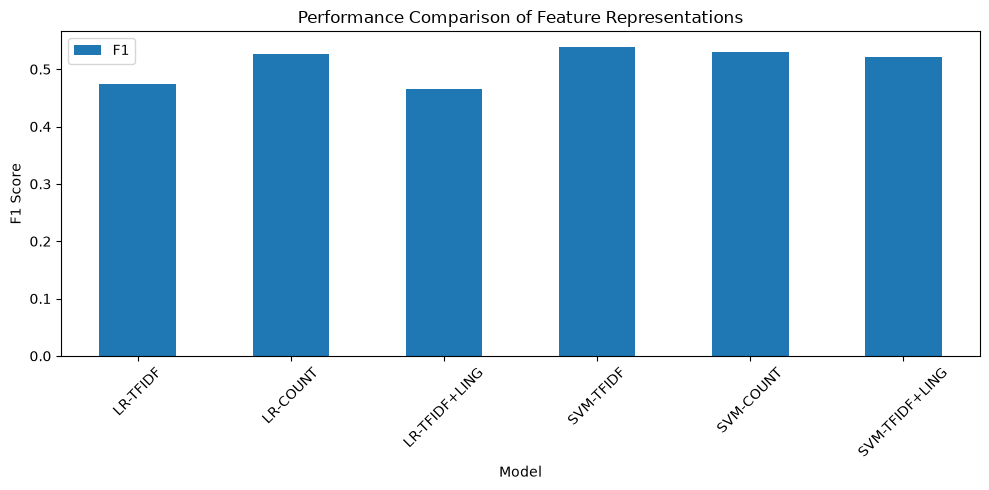

In [58]:
%pip install matplotlib
import matplotlib.pyplot as plt

comparison_df.plot(
    x="Model",
    y="F1",
    kind="bar",
    figsize=(10,5)
)

plt.title("Performance Comparison of Feature Representations")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

class imblance handlind

In [59]:
lr_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_balanced.fit(X_train_tfidf, y_train)

pred_lr_bal = lr_balanced.predict(X_test_tfidf)

print("F1:", f1_score(y_test, pred_lr_bal))

F1: 0.5064498037016265


In [60]:
svm_balanced = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_balanced.fit(X_train_tfidf, y_train)

pred_svm_bal = svm_balanced.predict(X_test_tfidf)

print("F1:", f1_score(y_test, pred_svm_bal))

F1: 0.4796674748874264


In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

pred_lr_bal = lr_balanced.predict(X_test_tfidf)

acc_lr_bal = accuracy_score(y_test, pred_lr_bal)
prec_lr_bal = precision_score(y_test, pred_lr_bal)
rec_lr_bal = recall_score(y_test, pred_lr_bal)
f1_lr_bal = f1_score(y_test, pred_lr_bal)

print("Accuracy:", acc_lr_bal)
print("Precision:", prec_lr_bal)
print("Recall:", rec_lr_bal)
print("F1:", f1_lr_bal)

Accuracy: 0.8826666666666667
Precision: 0.38157616733572786
Recall: 0.7528136723634847
F1: 0.5064498037016265


In [62]:
pred_svm_bal = svm_balanced.predict(X_test_tfidf)

acc_svm_bal = accuracy_score(y_test, pred_svm_bal)
prec_svm_bal = precision_score(y_test, pred_svm_bal)
rec_svm_bal = recall_score(y_test, pred_svm_bal)
f1_svm_bal = f1_score(y_test, pred_svm_bal)

print("Accuracy:", acc_svm_bal)
print("Precision:", prec_svm_bal)
print("Recall:", rec_svm_bal)
print("F1:", f1_svm_bal)

Accuracy: 0.8748166666666667
Precision: 0.3592404275189374
Recall: 0.7215506461025427
F1: 0.4796674748874264


In [63]:
balanced_results = pd.DataFrame({
    "Model": [
        "LR-Balanced",
        "SVM-Balanced"
    ],
    "Accuracy": [
        round(acc_lr_bal,4),
        round(acc_svm_bal,4)
    ],
    "Precision": [
        round(prec_lr_bal,4),
        round(prec_svm_bal,4)
    ],
    "Recall": [
        round(rec_lr_bal,4),
        round(rec_svm_bal,4)
    ],
    "F1": [
        round(f1_lr_bal,4),
        round(f1_svm_bal,4)
    ]
})

balanced_results

,Model,Accuracy,Precision,Recall,F1
0,LR-Balanced,0.8827,0.3816,0.7528,0.5064
1,SVM-Balanced,0.8748,0.3592,0.7216,0.4797


In [64]:
comparison_balanced = pd.DataFrame({
    "Model": [
        "LR-TFIDF",
        "LR-Balanced",
        "SVM-TFIDF",
        "SVM-Balanced"
    ],
    "F1": [
        round(f1,4),
        round(f1_lr_bal,4),
        round(f1_svm,4),
        round(f1_svm_bal,4)
    ]
})

comparison_balanced

,Model,F1
0,LR-TFIDF,0.4750
1,LR-Balanced,0.5064
2,SVM-TFIDF,0.5391
3,SVM-Balanced,0.4797


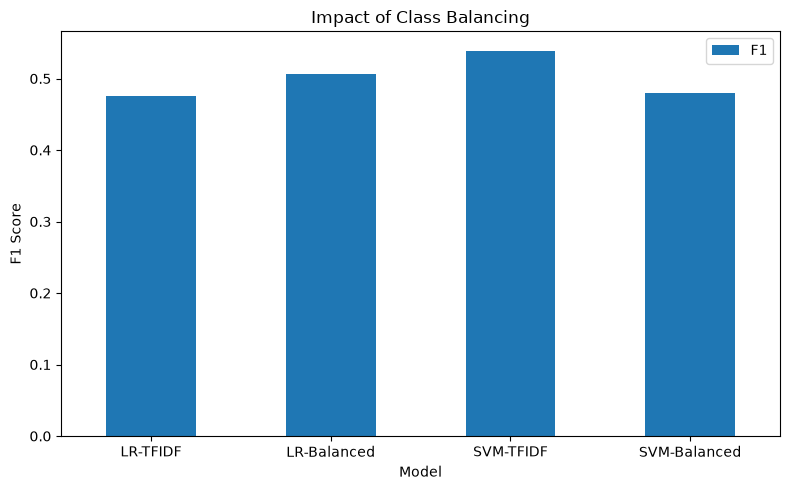

In [65]:
import matplotlib.pyplot as plt

comparison_balanced.plot(
    x="Model",
    y="F1",
    kind="bar",
    figsize=(8,5)
)

plt.title("Impact of Class Balancing")
plt.ylabel("F1 Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

SHAP Explainability

In [66]:
%pip install shap

   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
   -----------------


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [67]:
sample_size = 1000

X_sample = X_test_tfidf[:sample_size]

In [68]:
best_explain_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

best_explain_model.fit(
    X_train_tfidf,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [69]:
feature_names = tfidf.get_feature_names_out()

coef = best_explain_model.coef_[0]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef
})

importance_df = importance_df.sort_values(
    by="coefficient",
    ascending=False
)

importance_df.head(20)

,feature,coefficient
11197,stupid,25.991459
5705,idiots,18.458719
5703,idiot,17.971151
11199,stupidity,16.127696
8993,pathetic,14.600224
3004,crap,14.151763
3702,dumb,13.486061
5742,ignorant,13.402174
4448,fools,12.186158
10167,ridiculous,12.043008


In [70]:
importance_df.tail(20)

,feature,coefficient
2900,correct,-1.528361
5377,healthy,-1.531857
6879,laws,-1.548510
29,15,-1.549298
5519,history,-1.554943
4623,francis,-1.561268
12566,there,-1.576956
2825,contact,-1.583058
2309,cases,-1.596232
14733,wrong,-1.618096


In [71]:
top_toxic = importance_df.head(20)

top_toxic

,feature,coefficient
11197,stupid,25.991459
5705,idiots,18.458719
5703,idiot,17.971151
11199,stupidity,16.127696
8993,pathetic,14.600224
3004,crap,14.151763
3702,dumb,13.486061
5742,ignorant,13.402174
4448,fools,12.186158
10167,ridiculous,12.043008


In [72]:
top_nontoxic = importance_df.tail(20)

top_nontoxic

,feature,coefficient
2900,correct,-1.528361
5377,healthy,-1.531857
6879,laws,-1.548510
29,15,-1.549298
5519,history,-1.554943
4623,francis,-1.561268
12566,there,-1.576956
2825,contact,-1.583058
2309,cases,-1.596232
14733,wrong,-1.618096


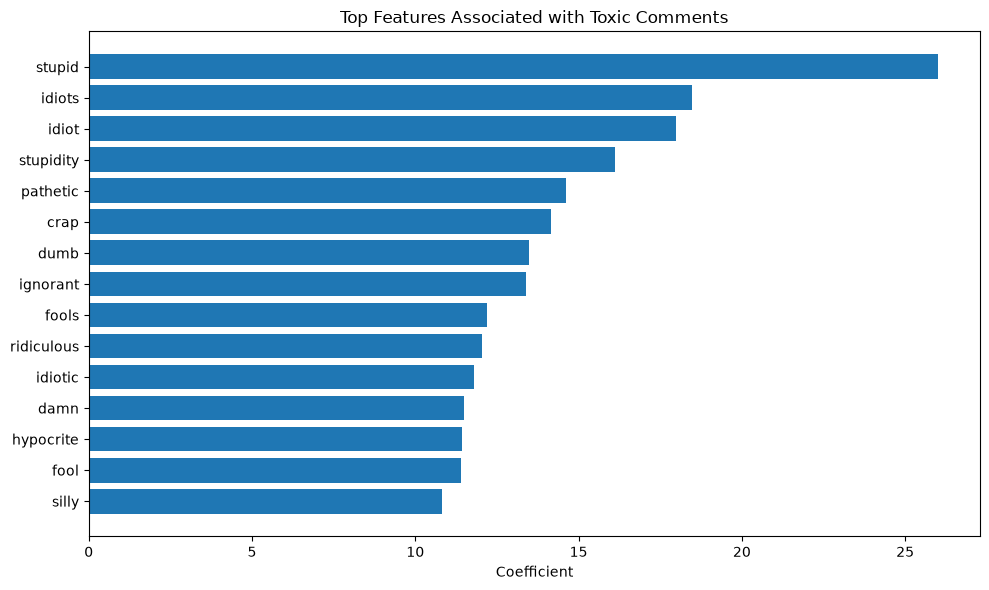

In [73]:
import matplotlib.pyplot as plt

top_toxic_plot = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_toxic_plot["feature"][::-1],
    top_toxic_plot["coefficient"][::-1]
)

plt.title("Top Features Associated with Toxic Comments")

plt.xlabel("Coefficient")

plt.tight_layout()

plt.show()

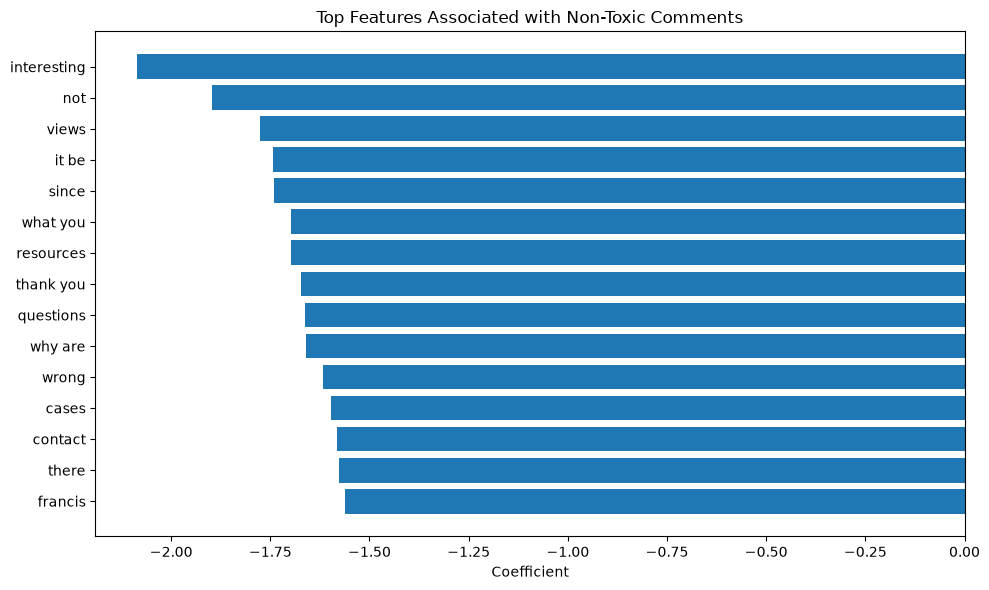

In [74]:
top_nontoxic_plot = importance_df.tail(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_nontoxic_plot["feature"],
    top_nontoxic_plot["coefficient"]
)

plt.title("Top Features Associated with Non-Toxic Comments")

plt.xlabel("Coefficient")

plt.tight_layout()

plt.show()

In [75]:
top_toxic.to_csv(
    "top_toxic_features.csv",
    index=False
)

top_nontoxic.to_csv(
    "top_nontoxic_features.csv",
    index=False
)

Robustness Analysis

In [76]:
# Create Typo Noise
import random

def add_typo(text):

    words = text.split()

    if len(words) == 0:
        return text

    idx = random.randint(0, len(words)-1)

    word = words[idx]

    if len(word) > 3:

        pos = random.randint(0, len(word)-2)

        word = (
            word[:pos]
            + word[pos+1]
            + word[pos]
            + word[pos+2:]
        )

        words[idx] = word

    return " ".join(words)

In [77]:
# create noisy test data
X_test_typo = X_test.apply(add_typo)

In [78]:
# No puncuation version
import re

X_test_nopunct = X_test.apply(
    lambda x: re.sub(
        r'[^\w\s]',
        '',
        str(x)
    )
)

In [79]:
# Convert to TF-IDF
X_test_typo_tfidf = tfidf.transform(X_test_typo)

X_test_nopunct_tfidf = tfidf.transform(X_test_nopunct)

In [80]:
svm
pred_typo = svm.predict(
    X_test_typo_tfidf
)

pred_nopunct = svm.predict(
    X_test_nopunct_tfidf
)

In [81]:
from sklearn.metrics import f1_score

f1_original = f1_score(
    y_test,
    y_pred_svm
)

f1_typo = f1_score(
    y_test,
    pred_typo
)

f1_nopunct = f1_score(
    y_test,
    pred_nopunct
)

print("Original:", f1_original)
print("Typo:", f1_typo)
print("No Punctuation:", f1_nopunct)

Original: 0.5390952059419312
Typo: 0.523673079547005
No Punctuation: 0.5375185235080157


In [82]:
robustness_df = pd.DataFrame({
    "Dataset":[
        "Original",
        "Typo Noise",
        "No Punctuation"
    ],
    "F1":[
        f1_original,
        f1_typo,
        f1_nopunct
    ]
})

robustness_df

,Dataset,F1
0,Original,0.539095
1,Typo Noise,0.523673
2,No Punctuation,0.537519
